In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('data/ejercicio_1/dataset_banco.csv')
df.shape

(45215, 17)

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45215 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45215 non-null  int64  
 1   job        45213 non-null  object 
 2   marital    45214 non-null  object 
 3   education  45214 non-null  object 
 4   default    45215 non-null  object 
 5   balance    45213 non-null  float64
 6   housing    45215 non-null  object 
 7   loan       45215 non-null  object 
 8   contact    45215 non-null  object 
 9   day        45215 non-null  int64  
 10  month      45215 non-null  object 
 11  duration   45214 non-null  float64
 12  campaign   45215 non-null  int64  
 13  pdays      45214 non-null  float64
 14  previous   45215 non-null  int64  
 15  poutcome   45215 non-null  object 
 16  y          45215 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 5.9+ MB


## Eliminar datos faltantes

In [ ]:
df.dropna(inplace=True)

## Eliminación de columnas irrelevantes

####   debemos verificar que no haya columnas categóricas con un sólo nivel, o columnas numéricas con un sólo valor.

In [ ]:
cols_cat = ['job', 'marital', 'education', 'default', 'housing',
       'loan', 'contact', 'month', 'poutcome', 'y']

for col in cols_cat:
    print(f'Columna {col}:  {df[col].nunique()} niveles')

Columna job:  18 niveles
Columna marital:  6 niveles
Columna education:  10 niveles
Columna default:  2 niveles
Columna housing:  2 niveles
Columna loan:  6 niveles
Columna contact:  5 niveles
Columna month:  12 niveles
Columna poutcome:  6 niveles
Columna y:  2 niveles


#### Y con esto podemos verificar que todas las columnas categóricas tienen más de 1 sub-nivel, así que no eliminaremos ninguna.

In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000
mean,41.005596,1374.201318,15.806534,258.032539,2.763731,40.178225,0.580198
std,12.037399,3924.491665,8.323015,257.460759,3.098058,100.103283,2.303341
min,18.000000,-8019.000000,1.000000,-1389.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1427.500000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,776.000000,527532.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Detección y manejo de registros repetidos

In [ ]:
print(f'Tamaño del DataFrame: {df.shape}')
print(f'Registros duplicados: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'Nuevo tamaño del DataFrame: {df.shape}')

Tamaño del DataFrame: (45207, 17)
Registros duplicados: 4
Nuevo tamaño del DataFrame: (45203, 17)


## Detección y manejo de valores extremos

#### El uso de gráficos de caja (o «boxplots») es una herramienta que fácilmente permite detectar la presencia de «outliers» en variables numéricas.

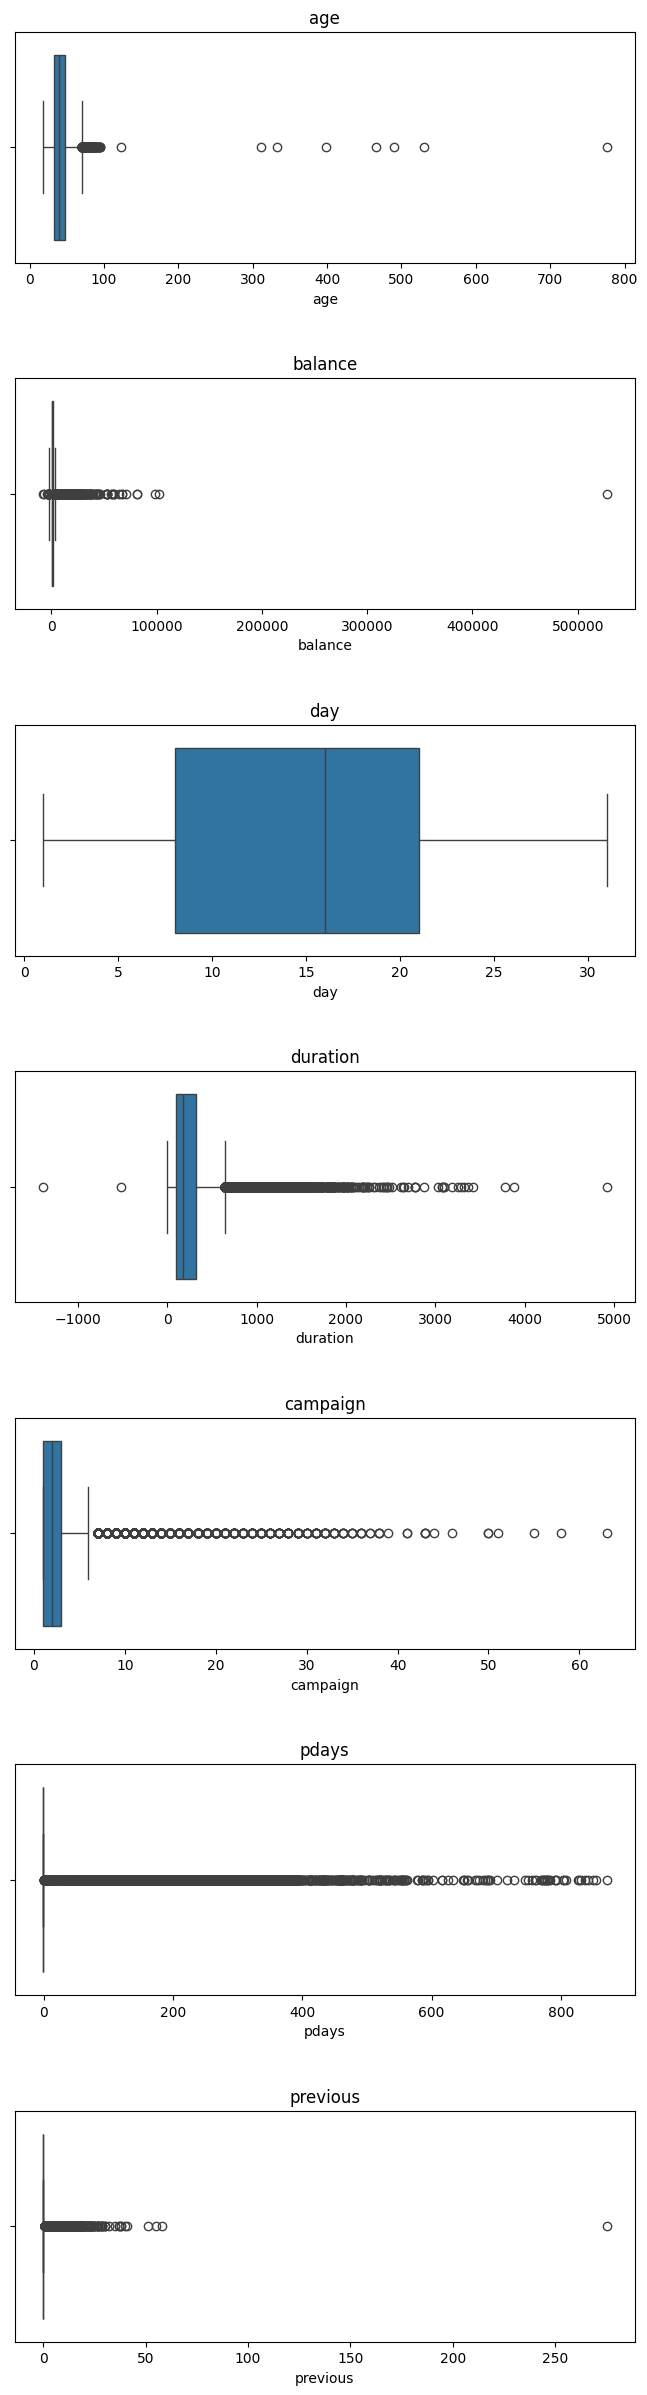

In [ ]:
cols_num = ['age', 'balance', 'day', 'duration', 'campaign',
            'pdays', 'previous']

fig, ax = plt.subplots(nrows=7, ncols=1, figsize=(8,30))
fig.subplots_adjust(hspace=0.5)

for i, col in enumerate(cols_num):
    sns.boxplot(x=col, data=df, ax=ax[i])
    ax[i].set_title(col)

In [ ]:
print(f'Tamaño del dataframe antes de eliminar registros anomalos en edad: {df.shape}')
df = df[df['age']<=100]
print(f'Tamaño del dataframe después de eliminar registros anomalos en edad: {df.shape}')

Tamaño del dataframe antes de eliminar registros anomalos en edad: (45203, 17)
Tamaño del dataframe después de eliminar registros anomalos en edad: (45195, 17)


In [ ]:
print(f'Tamaño del dataframe antes de eliminar registros anomalos en duracion: {df.shape}')
df = df[df['duration']>0]
print(f'Tamaño del dataframe después de eliminar registros anomalos en duracion: {df.shape}')

Tamaño del dataframe antes de eliminar registros anomalos en duracion: (45195, 17)
Tamaño del dataframe después de eliminar registros anomalos en duracion: (45190, 17)


In [ ]:
print(f'Tamaño del dataframe antes de eliminar registros anomalos en previous: {df.shape}')
df = df[df['previous']<=100]
print(f'Tamaño del dataframe después de eliminar registros anomalos en previous: {df.shape}')

Tamaño del dataframe antes de eliminar registros anomalos en previous: (45190, 17)
Tamaño del dataframe después de eliminar registros anomalos en previous: (45189, 17)


## Corrección de errores tipográficos o equivalencias

In [ ]:
for col in cols_cat:
    print(df[col].value_counts())
    print('-'*20)

job
blue-collar       9727
management        9451
technician        7592
admin.            5165
services          4151
retired           2262
self-employed     1577
entrepreneur      1486
unemployed        1303
housemaid         1240
student            937
unknown            288
administrative       3
Management           2
MANAGEMENT           2
Self-employed        1
Services             1
Retired              1
Name: count, dtype: int64
--------------------
marital
married     27200
single      12781
divorced     5194
div.            7
Single          4
DIVORCED        3
Name: count, dtype: int64
--------------------
education
secondary    23181
tertiary     13297
primary       6845
unknown       1855
SECONDARY        3
Primary          2
UNK              2
sec.             2
Secondary        1
Tertiary         1
Name: count, dtype: int64
--------------------
default
no     44374
yes      815
Name: count, dtype: int64
--------------------
housing
yes    25111
no     20078
Name: coun

In [ ]:
for col in cols_cat:
    df[col] = df[col].str.lower().str.strip()
    print(df[col].value_counts())
    print('-'*20)
    

job
blue-collar       9727
management        9455
technician        7592
admin.            5165
services          4152
retired           2263
self-employed     1578
entrepreneur      1486
unemployed        1303
housemaid         1240
student            937
unknown            288
administrative       3
Name: count, dtype: int64
--------------------
marital
married     27200
single      12785
divorced     5197
div.            7
Name: count, dtype: int64
--------------------
education
secondary    23185
tertiary     13298
primary       6847
unknown       1855
sec.             2
unk              2
Name: count, dtype: int64
--------------------
default
no     44374
yes      815
Name: count, dtype: int64
--------------------
housing
yes    25111
no     20078
Name: count, dtype: int64
--------------------
loan
no     37948
yes     7241
Name: count, dtype: int64
--------------------
contact
cellular     29271
unknown      13011
telephone     2901
phone            3
mobile           3
Name: cou

In [ ]:
df['job'] = df['job'].str.replace('admin.','administrative', regex=False)
df['marital'] = df['marital'].str.replace('div.','divorced', regex=False)
df['education'] = df['education'].str.replace('sec.','secondary', regex=False)

In [ ]:
df.loc[df['education']=='unk','education'] = 'unknown'
df.loc[df['contact']=='phone','contact'] = 'telephone'
df.loc[df['contact']=='mobile','contact'] = 'cellular'

In [ ]:
print(df['poutcome'].unique())
df[df['poutcome'] == 'unk'] = 'unknown'
print(df['poutcome'].unique())

['unknown' 'unk' 'failure' 'other' 'success']
['unknown' 'failure' 'other' 'success']


C:\Users\david\AppData\Local\Temp\ipykernel_10248\3167039729.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'unknown' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df[df['poutcome'] == 'unk'] = 'unknown'
C:\Users\david\AppData\Local\Temp\ipykernel_10248\3167039729.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df[df['poutcome'] == 'unk'] = 'unknown'
C:\Users\david\AppData\Local\Temp\ipykernel_10248\3167039729.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'unknown' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df[df['poutcome'] == 'unk'] = 'unkno

In [ ]:
df.shape

(45189, 17)

In [ ]:
ruta = "data/ejercicio_1/dataset_banco_clean.csv'"
df.to_csv(ruta)